In [1]:
import sys
sys.path.append("../")

In [2]:
from interface import WormSimulationInterface 

#intialize the interface with a worm_id between 0 and 4
interface = WormSimulationInterface(worm_id=0)

The evaluator was intitialized for Worm 0.


In [2]:
interface.print_worm_states()

['1-0', '1-1', '1-2', '1-3', '1-4', '1-5', '1-6', '1-7', '2-0', '2-1', '2-2', '2-3', '2-4', '2-5', '2-6', '2-7', '3-0', '3-1', '3-2', '3-3', '3-4', '3-5', '3-6', '3-7', '4-0', '4-1', '4-2', '4-3', '4-4', '4-5', '4-6', '4-7', '5-0', '5-1', '5-2', '5-3', '5-4', '5-5', '5-6', '5-7', '6-0', '6-1', '6-2', '6-3', '6-4', '6-5', '6-6', '6-7', '7-0', '7-1', '7-2', '7-3', '7-4', '7-5', '7-6', '7-7', '8-0', '8-1', '8-2', '8-3', '8-4', '8-5', '8-6', '8-7']


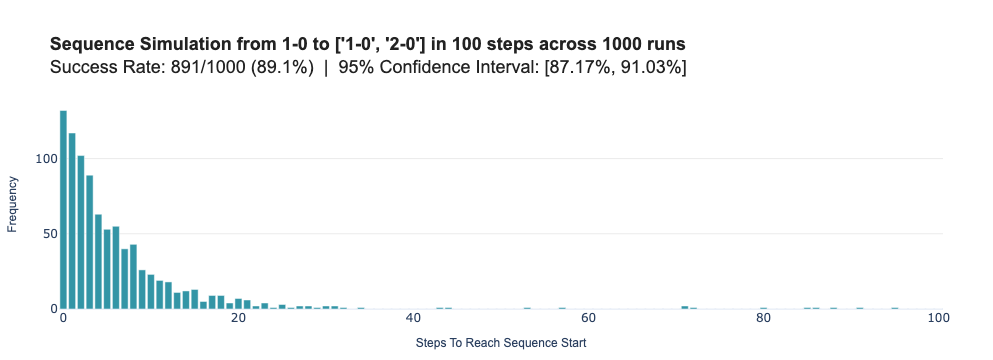

In [2]:
sequence_query = interface.evaluate_sequence_query(
    start_state = "1-0", 
    sequence = ["1-0", "2-0"], 
    steps = 100, 
    num_runs = 1000, 
    run_parallel = False 
)

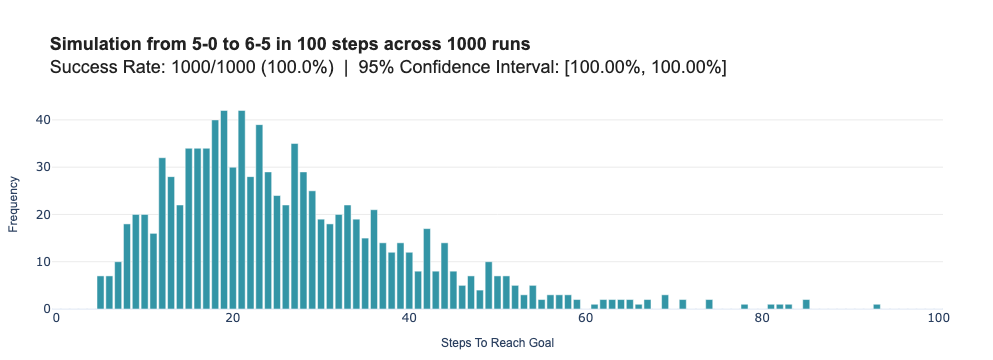

In [3]:
# run a factual query (sequentially)
factual_query = interface.evaluate_query(
    start_state = "5-0", 
    target_state = "6-5", 
    steps = 100, 
    num_runs = 1000, 
    ci = 0.95, 
    run_parallel = False
)

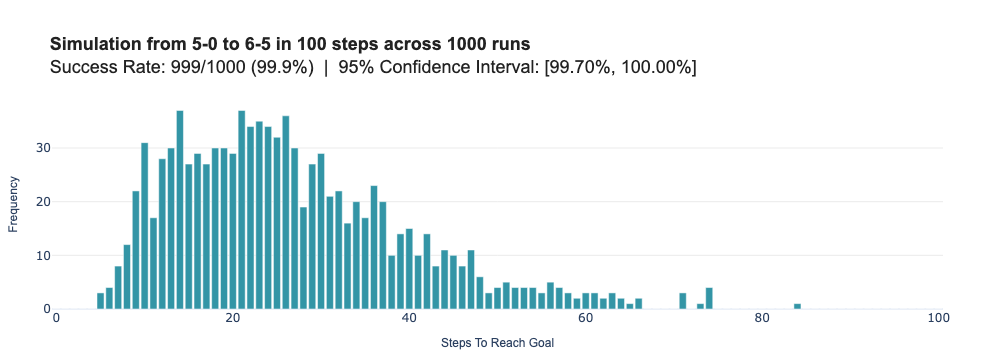

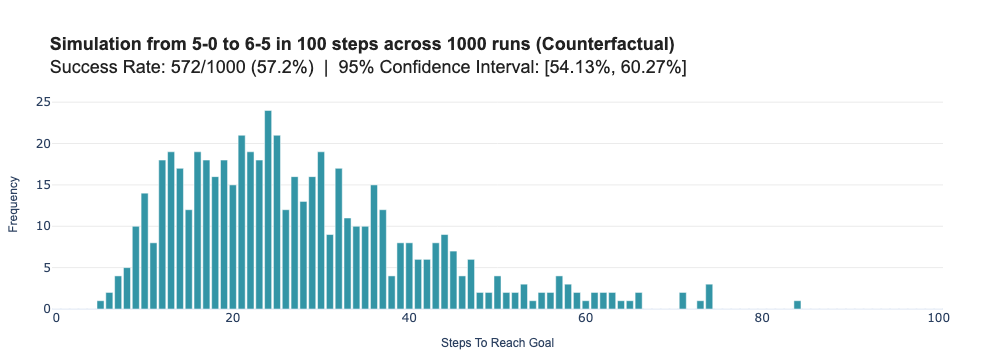

In [4]:
# run a counterfactual query (sequentially)
severed_edges = [("6-3", "6-5")]

counterfactual_query = interface.evaluate_counterfactual(
    start_state = "5-0", 
    target_state = "6-5", 
    steps = 100, 
    num_runs = 1000, 
    ci = 0.95, 
    run_parallel = False, 
    severed_edges = severed_edges
)

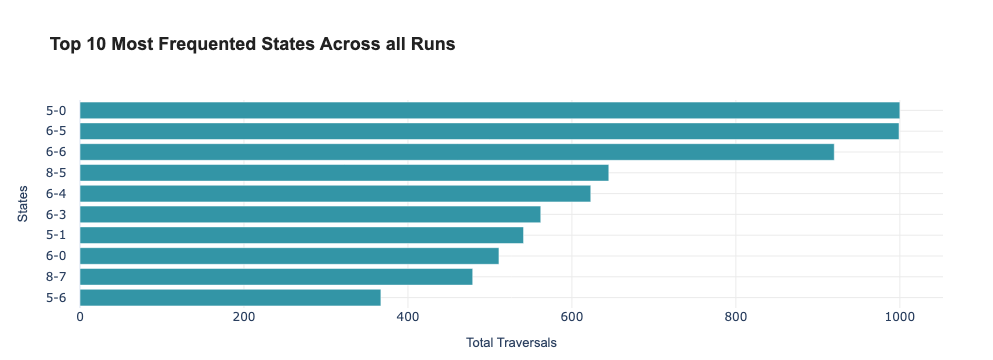

In [4]:
# get most frequently traversed states of the query

interface.plot_frequently_traversed(factual_query)

In [2]:
# plot the network topology 

"""interface.plot_network_topology(
    min_probability = 0.01, 
    max_probability = 1.0, 
    #filename = "test"
)"""

'interface.plot_network_topology(\n    min_probability = 0.01, \n    max_probability = 1.0, \n    #filename = "test"\n)'

In [12]:
# plot interactive network topology 

interface.plot_interactive_network_topology(
    min_probability = 0.01, 
    max_probability = 1.0, 
    filename = "topology.html"
)

topology.html


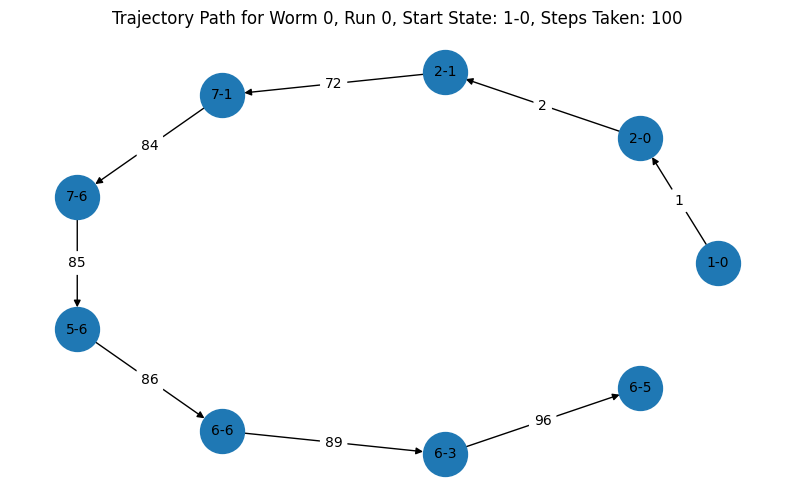

In [3]:
# plot sample trajectory of a single run 

interface.plot_sample_trajectory(
    query_data = factual_query, 
    run_index = 0
)

In [127]:
# plot sample trajectory of a single run 

interface.plot_interactive_sample_trajectory(
    query_data = factual_query, 
    run_index = 47
)

#16 is short: 4
#13 is pretty loopy, 17, 46 is a perfect loop, 47 is crazy
#21 is long: 12, 37: 14

trajectory.html


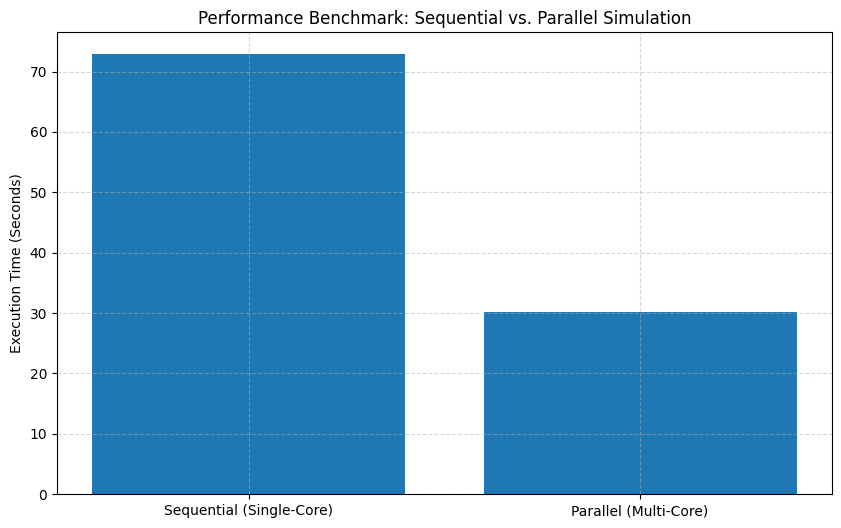

In [7]:
# plot parallel benchmark 

interface.plot_parallel_benchmark(
    start_state = "1-0", 
    target_state = "2-0", 
    steps = 100, 
    num_runs = 100000
)

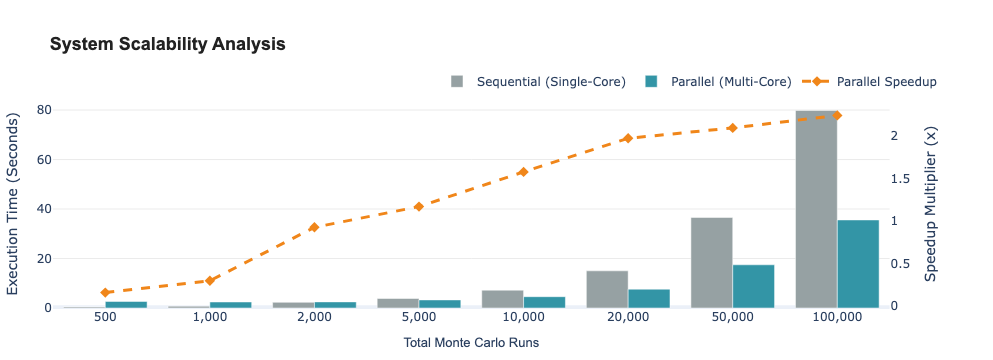

In [13]:
# perform a scalability analysis 

interface.plot_scalability_analysis(
    start_state = "1-0", 
    target_state = "2-0", 
    steps = 100, 
    run_sizes = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000], 
    num_workers = 4
)